<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/HJM_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 	1일 3.72%, 3개월 3.9%, 6개월 3%, 1년 3.1%, 2년 3.3%, 5년 3.45%, 10년 3.55%으로 zero curve가 형성되어 있다고 하자. HJM 모형에 따라 초기  f ̂(t_0,t_j ),j=1,…,3650 값들을 생성하고, 이를 바탕으로 초기 zero curve를 복원해 보아라.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# =========================================================================
# [환경 세팅] 격자 및 시간 간격 설정 (j = 1, ..., 3650)
# =========================================================================
M = 3650
h_value = 1.0 / 365.0
h = np.full(M, h_value)
T_j = np.cumsum(h)

# =========================================================================
# [1단계] 주어진 시장의 원래 Zero Curve 마일스톤 데이터
# =========================================================================
market_tenors = np.array([1/365, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0])
market_zero_rates = np.array([0.0372, 0.0390, 0.0300, 0.0310, 0.0330, 0.0345, 0.0355])

# 큐빅 스플라인 보간 및 미분 분해
zero_spline = CubicSpline(market_tenors, market_zero_rates, bc_type='natural')
zero_derivative = zero_spline.derivative(nu=1)

R_target = zero_spline(T_j)
dR_dT = zero_derivative(T_j)

# HJM 초기 순간선도이자율 생성
f_t0 = R_target + T_j * dR_dT

In [4]:
# =========================================================================
# [2단계] 생성된 f(t_0, t_j)를 역적분하여 초기 Zero Curve 복원
# =========================================================================
f_integrated = np.cumsum(f_t0 * h_value)
R_restored = f_integrated / T_j

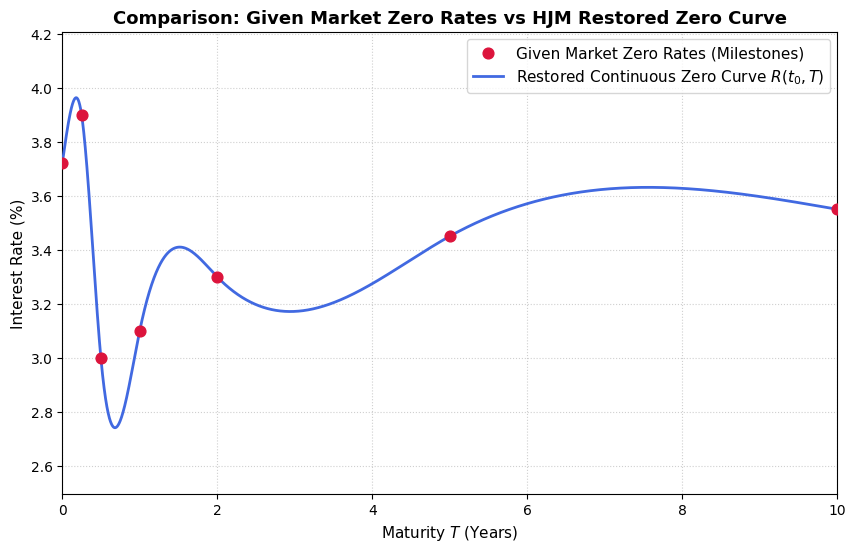

In [5]:
# =========================================================================
# [3단계] 주어진 원본 마일스톤 vs 복원된 연속 Zero Curve 비교 시각화
# =========================================================================
plt.figure(figsize=(10, 6))

# 1. 주어진 시장 초기 제로 금리 마일스톤 (산점도 점 표시)
plt.scatter(market_tenors, market_zero_rates * 100,
            color="crimson", s=60, zorder=5,
            label="Given Market Zero Rates (Milestones)")

# 2. 선도금리(f_t0)를 역적분하여 3650개 격자로 복원한 연속 제로 곡선
plt.plot(T_j, R_restored * 100,
          color="royalblue", lw=2, linestyle="-", zorder=4,
          label="Restored Continuous Zero Curve $R(t_0, T)$")

# Y축 자동 마진 최적화
y_min, y_max = R_restored.min() * 100, R_restored.max() * 100
y_margin = (y_max - y_min) * 0.20

# 그래프 서식 설정
plt.title("Comparison: Given Market Zero Rates vs HJM Restored Zero Curve", fontsize=13, fontweight='bold')
plt.xlabel("Maturity $T$ (Years)", fontsize=11)
plt.ylabel("Interest Rate (%)", fontsize=11)
plt.ylim(y_min - y_margin, y_max + y_margin)
plt.xlim(0, 10.0)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="best")

plt.show()

📊 [검증 결과] 원본 곡선 vs 복원 곡선 최대 절대 오차: 7.09e-05
-------------------------------------------------------------------------------------


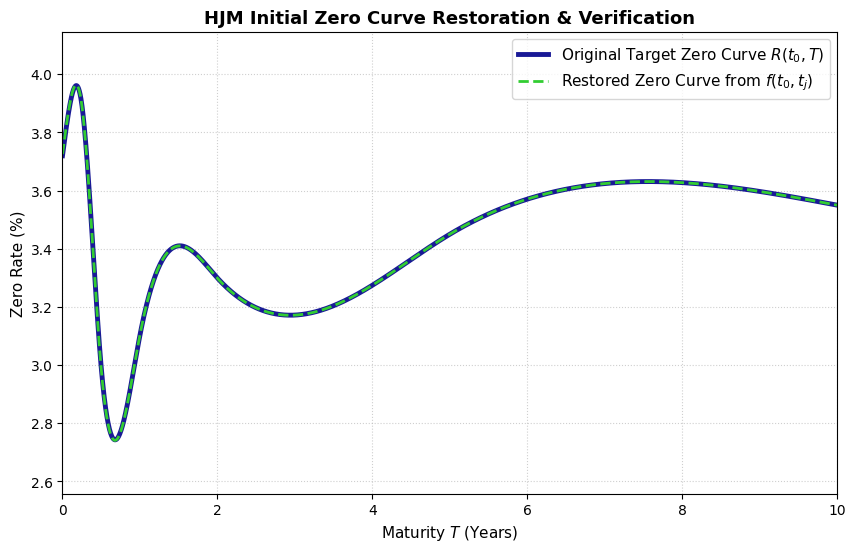

In [6]:
# =========================================================================
# 원본 제로 곡선과 복원된 제로 곡선 시각화 및 오차 검증
# =========================================================================
# 최대 복원 오차 계산
max_error = np.max(np.abs(R_target - R_restored))
print(f"📊 [검증 결과] 원본 곡선 vs 복원 곡선 최대 절대 오차: {max_error:.2e}")
print("-" * 85)

plt.figure(figsize=(10, 6))

# 1. 원본 제로 곡선 Plot (두꺼운 실선)
plt.plot(T_j, R_target * 100, label="Original Target Zero Curve $R(t_0, T)$",
          color="darkblue", lw=3.5, alpha=0.9)

# 2. 복원된 제로 곡선 Plot (얇은 대시선으로 겹침 확인)
plt.plot(T_j, R_restored * 100, label="Restored Zero Curve from $f(t_0, t_j)$",
          color="limegreen", linestyle="--", lw=2)

# 그래프 서식 자동 최적화 (이전 변경 사항 반영)
y_min = min(R_target.min(), R_restored.min()) * 100
y_max = max(R_target.max(), R_restored.max()) * 100
y_margin = (y_max - y_min) * 0.15 if (y_max - y_min) > 0 else 0.5

plt.title("HJM Initial Zero Curve Restoration & Verification", fontsize=13, fontweight='bold')
plt.xlabel("Maturity $T$ (Years)", fontsize=11)
plt.ylabel("Zero Rate (%)", fontsize=11)
plt.ylim(y_min - y_margin, y_max + y_margin)
plt.xlim(0, 10.0)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="best")

plt.show()

## 1일 3.72%, 3개월 3.9%, 6개월 3%, 1년 3.1%, 2년 3.3%, 5년 3.45%, 10년 3.55%으로 zero curve가 형성되어 있다고 하자. HJM 모형에 따라 초기  f ̂(t_0,t_j ),j=1,…,3650 값들을 생성하고, 이를 바탕으로 f ̂(t_1,t_j ),j=1,…,3650를 발생시켜 보아라. 이 때, 모든 선도이자율의 변동성은 10%로 동일하다고 하자.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# =========================================================================
# [1단계] 초기 데이터 입력 및 Cubic Spline 기반 초기 선도곡선 f(t0, t_j) 생성
# =========================================================================
# 문제 16번 조건 데이터 (만기 단위: 년)
market_tenors = np.array([0.0, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0])
market_zero_rates = np.array([0.0372, 0.0390, 0.0300, 0.0310, 0.0330, 0.0345, 0.0355])

M = 3650  # 10년 만기 일일 격자수
h_val = 1.0 / 365.0  # 일일 간격 dt

# 시간 격자 정의 (인덱스 계산 편의를 위해 t0 시점을 0번 인덱스에 배치)
# t_0 = 0, t_1 = 1/365, t_2 = 2/365, ..., t_M = 10.0
t = np.arange(0, M + 1) * h_val

# 초기 제로 곡선 보간 및 1차 미분(dR/dT) 함수 도출
zero_spline = CubicSpline(market_tenors, market_zero_rates, bc_type='natural')
zero_derivative = zero_spline.derivative(nu=1)

# f(t0, t_j) 생성 (j = 1, ..., 3650)를 저장할 배열 공간 확보 (0번 인덱스는 t0 시점이므로 비워둠)
f = np.zeros((M + 1, M + 1))

# t0 시점(0번째 행)의 선도금리 초기값 채우기
R_t0 = zero_spline(t[1:])
dR_dT = zero_derivative(t[1:])
f[0, 1:] = R_t0 + t[1:] * dR_dT  # f(t0, t_j) 계산 완료


In [6]:
# =========================================================================
# [2단계] 1스텝 전진 시뮬레이션 (t0 -> t1)
# =========================================================================
volatility = 0.10  # 10% 상수 변동성

# 1스텝 전진이므로 i = 1로 고정 (즉, t0 시점에서 t1 시점으로 1일 전진)
i = 1

# t_1 시점에서 사용할 표준정규분포 난수 Z_1 생성
Z_i = np.random.normal(0.0, 1.0)

# 알고리즘 내부에서 계산할 누적 배열 공간 확보 (0-indexed 연산을 위해 크기 M+1 설정)
A = np.zeros(M + 1)
B = np.zeros(M + 1)
mu = np.zeros(M + 1)

# 의사코드 조건: A_{i-1} = B_{i-1} = 0 (여기서는 i=1이므로 A_0 = B_0 = 0)
A[i - 1] = 0.0
B[i - 1] = 0.0

# 의사코드 루프: j = i, ..., M-1 반복 계산 (파이썬 range 특성상 M으로 마감)
for j in range(i, M):
    # 1. A_j = A_{j-1} + sigma_hat * (t_{j+1} - t_j)
    dt_j = t[j + 1] - t[j]
    A[j] = A[j - 1] + volatility * dt_j

    # 2. B_j = A_j^2
    B[j] = A[j] ** 2

    # 3. mu = 1 / (2 * (t_{j+1} - t_j)) * [B_j - B_{j-1}]
    mu[j] = (B[j] - B[j - 1]) / (2.0 * dt_j)

    # 4. f(t_i, t_j) 업데이트 전진
    dt_i = t[i] - t[i - 1]  # 현재 시뮬레이션 시간 전진폭 (t1 - t0 = 1/365)

    f[i, j] = f[i - 1, j] + mu[j] * dt_i + volatility * np.sqrt(dt_i) * Z_i

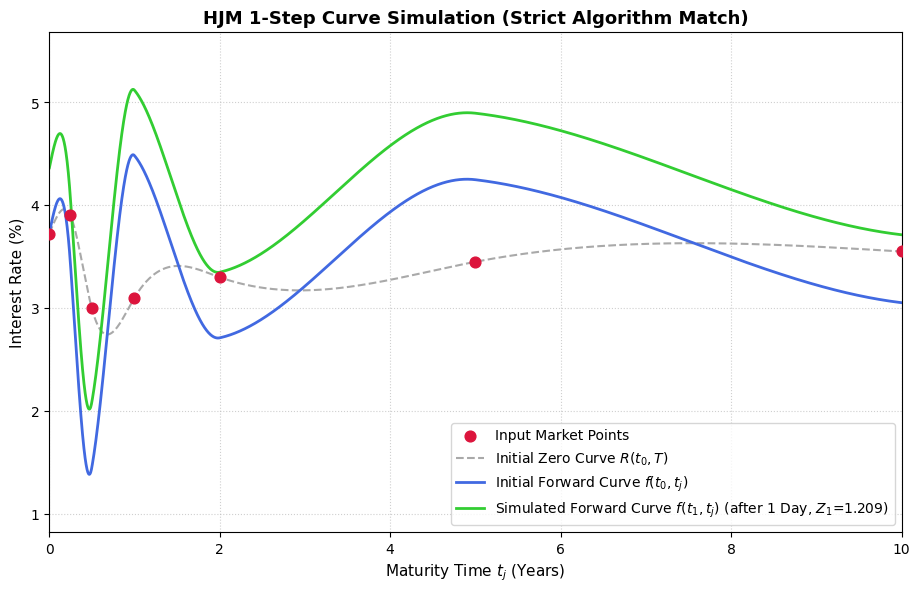

In [4]:
# =========================================================================
# [3단계] Y축 동적 스케일 조절을 적용한 결과 시각화
# =========================================================================
# t1 시점에서 유효하게 계산된 만기 구간은 j = i, ..., M-1 (즉, 1일부터 3649일까지)
valid_maturities = t[i:M]
f_t0_plotted = f[0, i:M]
f_t1_plotted = f[i, i:M]
R_t0_plotted = R_t0[:len(valid_maturities)]

plt.figure(figsize=(11, 6.5))

# 데이터 커브 플롯
plt.scatter(market_tenors, market_zero_rates * 100, color="crimson", marker="o", s=60, label="Input Market Points", zorder=5)
plt.plot(t[1:], R_t0 * 100, label="Initial Zero Curve $R(t_0, T)$", color="darkgray", linestyle="--")
plt.plot(valid_maturities, f_t0_plotted * 100, label="Initial Forward Curve $f(t_0, t_j)$", color="royalblue", lw=2)
plt.plot(valid_maturities, f_t1_plotted * 100, label=f"Simulated Forward Curve $f(t_1, t_j)$ (after 1 Day, $Z_1$={Z_i:.3f})", color="limegreen", lw=2)

# Y축 자동 최적화 마진 계산 (화면 밖으로 데이터가 깨져서 잘리는 현상 방지)
y_min = min(R_t0_plotted.min(), f_t0_plotted.min(), f_t1_plotted.min()) * 100
y_max = max(R_t0_plotted.max(), f_t0_plotted.max(), f_t1_plotted.max()) * 100
y_margin = (y_max - y_min) * 0.15 if (y_max - y_min) > 0 else 0.5

# 그래프 포맷팅
plt.title("HJM 1-Step Curve Simulation (Strict Algorithm Match)", fontsize=13, fontweight='bold')
plt.xlabel("Maturity Time $t_j$ (Years)", fontsize=11)
plt.ylabel("Interest Rate (%)", fontsize=11)
plt.xlim(0, 10.0)
plt.ylim(y_min - y_margin, y_max + y_margin)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10, loc="best")

plt.show()


✅ f[i, i:M] 기반 t_1 시점 Zero Curve 변환 완료 (크기: 3649)


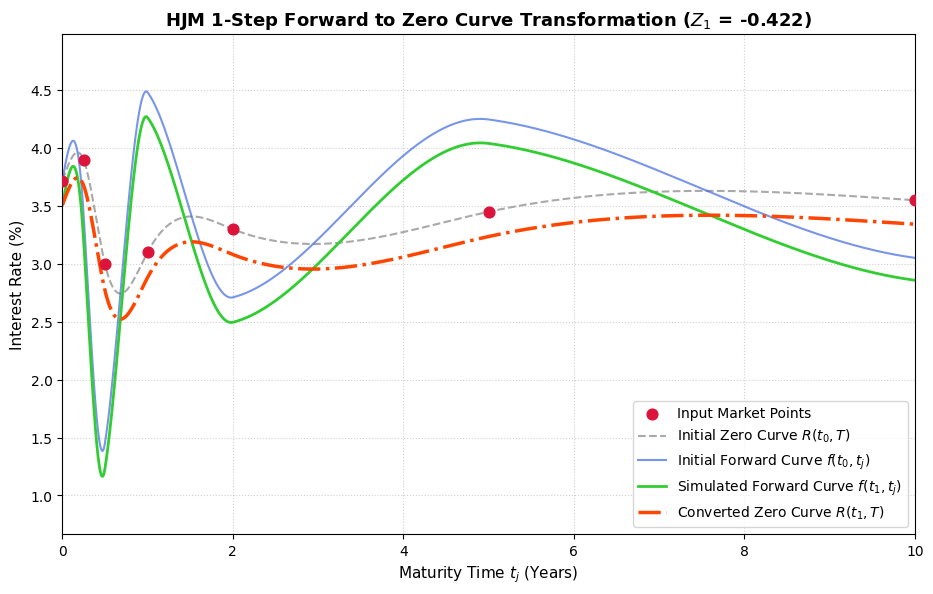

In [7]:
# =========================================================================
# [추가 단계] 시뮬레이션된 f[i, i:M]을 바탕으로 t1 시점의 Zero Curve 복원
# =========================================================================
# t1 시점에서 살아있는 선도이자율 배열 포착 (j = 1, ..., 3649)
f_t1_active = f[i, i:M]

# 이산 적분 연결고리 적용: 선도이자율 곡선의 누적 합산 (cumsum)
f_t1_cumsum = np.cumsum(f_t1_active)

# 누적 개수(k) 배열 생성: 1, 2, ..., 3649
k_indices = np.arange(1, len(f_t1_active) + 1)

# R(t1, T_k) = (1/k) * \sum_{j=1}^k f(t1, t_j)
R_t1 = f_t1_cumsum / k_indices

print(f"✅ f[i, i:M] 기반 t_1 시점 Zero Curve 변환 완료 (크기: {len(R_t1)})")

# =========================================================================
# [3단계] Y축 동적 스케일 조절을 적용한 결과 시각화 (t1 제로곡선 포함)
# =========================================================================
# 유효 만기 축 (t1 시점 이후 남은 만기 시점들)
valid_maturities = t[i:M]

plt.figure(figsize=(11, 6.5))

# 1. 초기 시장 입력값 및 초기 곡선 플롯
plt.scatter(market_tenors, market_zero_rates * 100, color="crimson", marker="o", s=60, label="Input Market Points", zorder=5)
plt.plot(t[1:], R_t0 * 100, label="Initial Zero Curve $R(t_0, T)$", color="darkgray", linestyle="--")
plt.plot(valid_maturities, f[0, i:M] * 100, label="Initial Forward Curve $f(t_0, t_j)$", color="royalblue", lw=1.5, alpha=0.7)

# 2. 시뮬레이션된 t1 선도곡선 플롯
plt.plot(valid_maturities, f_t1_active * 100, label=f"Simulated Forward Curve $f(t_1, t_j)$", color="limegreen", lw=2)

# 3. [핵심] f[i, i:M]으로부터 변환해 낸 t1 제로곡선 플롯
plt.plot(valid_maturities, R_t1 * 100, label=f"Converted Zero Curve $R(t_1, T)$", color="orangered", linestyle="-.", lw=2.5)

# Y축 자동 최적화 스케일링 (변환된 R_t1까지 포함하여 전체 추적)
y_min = min(R_t0.min(), f[0, i:M].min(), f_t1_active.min(), R_t1.min()) * 100
y_max = max(R_t0.max(), f[0, i:M].max(), f_t1_active.max(), R_t1.max()) * 100
y_margin = (y_max - y_min) * 0.15 if (y_max - y_min) > 0 else 0.5

# 그래프 포맷팅
plt.title(f"HJM 1-Step Forward to Zero Curve Transformation ($Z_1$ = {Z_i:.3f})", fontsize=13, fontweight='bold')
plt.xlabel("Maturity Time $t_j$ (Years)", fontsize=11)
plt.ylabel("Interest Rate (%)", fontsize=11)
plt.xlim(0, 10.0)
plt.ylim(y_min - y_margin, y_max + y_margin)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10, loc="best")

plt.show()